Código adaptado de:

[1] David Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] Sayak Paul, Conditional GAN tutorial, disponível no site do Keras [(link)](https://keras.io/examples/generative/conditional_gan/).

[3] Aurélien Géron, Hands-On Machine Learning with Scikit-Learn: Concepts, Tools and Techniques to Build Intelligent Systems, Keras & tensorFlow, Third Edition, O'Reilly, 2023.

# Laboratório 3A: CGAN

## Importações

In [ ]:
!pip install torchinfo gdown

In [ ]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
import torch.nn.functional as F             # Importa funções comuns de ativação e perda do PyTorch, usadas fora do módulo nn.Module (ex.: ReLU, cross_entropy, etc.)
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import gdown                                # Importa utilitário para baixar arquivos do Google Drive via link público
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Ajusta a variável de ambiente para evitar erros ao carregar múltiplas bibliotecas MKL

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

## Baixar e carregar os dados

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.13MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.6MB/s]


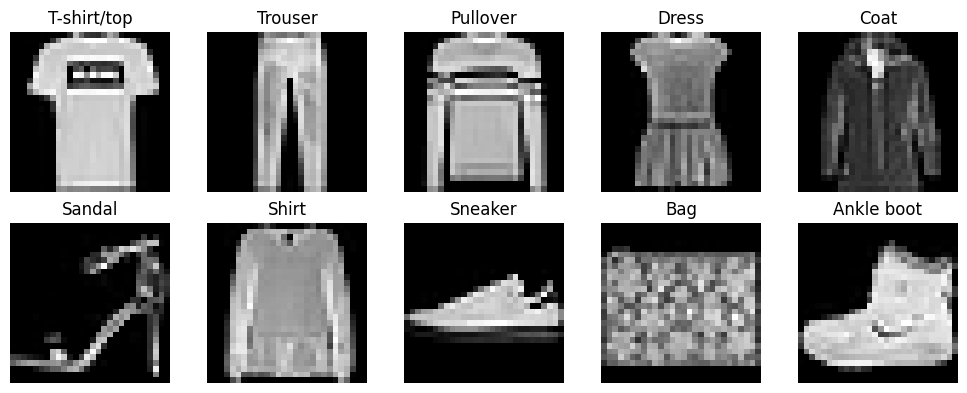

In [ ]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
batch_size = 32                                                      # Define o tamanho do lote, ou seja, quantas amostras serão processadas por vez
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True, drop_last=True)  # Cria o DataLoader para o conjunto de treinamento
test_dataloader = DataLoader(test_data, batch_size=batch_size)       # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y [N, ] : {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([32, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ] : torch.Size([32]), Tipo de dados em y: torch.int64


## Redes Neurais

### Gerador

In [ ]:
class Gerador(nn.Module):
    def __init__(self, z_dim=100, num_classes=10):
        super().__init__()

        # Definimos a rede sequencial do gerador
        self.rede_neural = nn.Sequential(

            # Camada totalmente conectada                                                       # Entrada: (lote, z_dim + num_classes)  (vetor de ruído z concatenado com rótulo com codificação one-hot)
            nn.Linear(z_dim + num_classes, 7 * 7 * 128),

            # Transforma o vetor 1D em um tensor 3D para convoluções
            nn.Unflatten(1, (128, 7, 7)),

            # Normalização em lote
            nn.BatchNorm2d(128),

            # Primeira convolução transposta
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),  # Função de ativação ReLU

            # Normalização em lote
            nn.BatchNorm2d(64),

            # Segunda convolução transposta
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),

            # Função de ativação final Tanh: valores de saída entre [-1, 1]
            nn.Tanh()
        )

    def forward(self, z, rotulo_one_hot):
        # Concatena o vetor de ruído com o vetor de rótulo one-hot:
        entrada = torch.cat([z, rotulo_one_hot], dim=1)  # Entrada: (lote, z_dim + num_classes)
        return self.rede_neural(entrada)                 # Saída: (lote, 1, 28, 28)

### Discriminador

Entrada do discriminador:

Downloading...
From: https://drive.google.com/uc?id=1c-8VzhUpo_MfuxvFHGH-HlVjVfEaJdxO
To: /content/entrada_discriminador.png
100%|██████████| 31.4k/31.4k [00:00<00:00, 59.2MB/s]


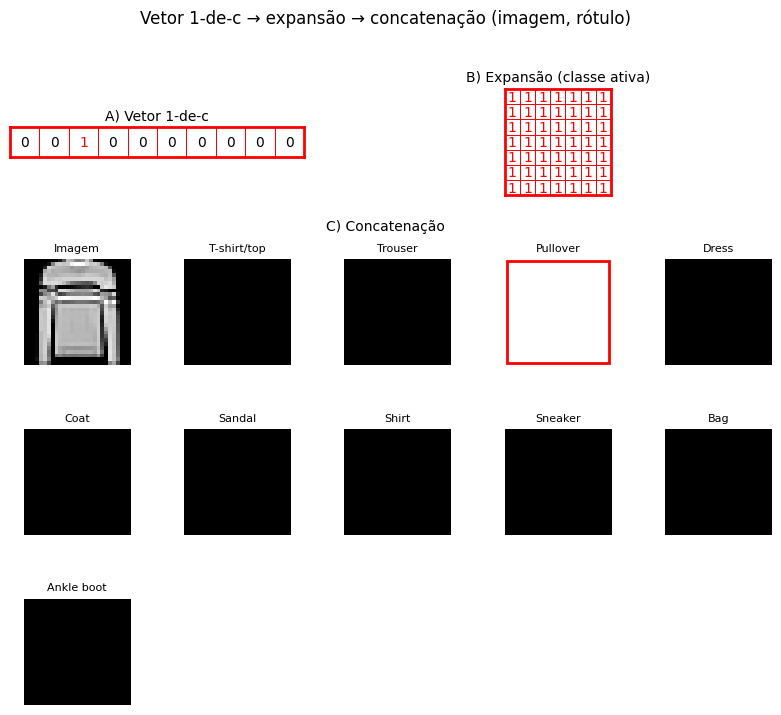

In [ ]:
gdown.download(
    url='https://drive.google.com/file/d/1c-8VzhUpo_MfuxvFHGH-HlVjVfEaJdxO/view?usp=sharing',
    output='entrada_discriminador.png',
    quiet=False,
    fuzzy=True)
Image('entrada_discriminador.png', width=700)

In [ ]:
class Discriminador(nn.Module):
    def __init__(self, num_classes=10, tam_img=28):
        super().__init__()

        # Número de classes
        self.num_classes = num_classes

        # Tamanho da imagem
        self.tam_img = tam_img

        # Definição da rede convolucional sequencial
        self.rede_neural = nn.Sequential(

            # Primeira camada convolucional                                                                 # entrada: [lote, 1 + 10, 28, 28] (1 canal da imagem + canais do rótulo)
            nn.Conv2d(in_channels=1 + num_classes, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(0.4),

            # Segunda camada convolucional
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(0.4),

            # Achatar o tensor 3D para um vetor 1D
            nn.Flatten(),

            # Camada totalmente conectada
            nn.Linear(7 * 7 * 128, 1),

            # Saída com função sigmoide (entre 0 e 1) -> usada para classificação binária (real ou falso)
            nn.Sigmoid()
        )


    def forward(self, imagem, rotulos_one_hot):
        # imagem: (B, 1, H, W) | rotulos_one_hot: (B, C)
        _, _, H, W = imagem.shape

        # (B, C, 1, 1) -> (B, C, H, W)  [expand cria uma view]
        mapa_rotulo = rotulos_one_hot[:, :, None, None].expand(-1, -1, H, W)

        # (B, 1+C, H, W)  [concatenar a imagem com o mapa de rótulo no eixo de canais]
        entrada = torch.cat((imagem, mapa_rotulo), dim=1)

        # Passar pela rede convolucional
        return self.rede_neural(entrada)

## Treinamento

In [ ]:
def train_dcgan_condicional(
    dataloader,
    gerador,
    discriminador,
    loss_fn,
    opt_gerador,
    opt_discriminador,
    device,
    epoch,
    z_dim,
    num_classes=10,
):

    gerador.train()
    discriminador.train()

    for batch_idx, (dados_reais, rotulos_reais) in enumerate(dataloader):
        batch_size = dados_reais.size(0)
        dados_reais = dados_reais.to(device)
        rotulos_reais = rotulos_reais.to(device)

        # Converte os rótulos reais para one-hot
        rotulos_reais_one_hot = F.one_hot(rotulos_reais, num_classes=num_classes).float()

        # Envia para o dispositivo (GPU/CPU)
        rotulos_reais_one_hot = rotulos_reais_one_hot.to(device)

        # ========================================
        # DISCRIMINADOR
        # ========================================

        # Rotulos desejados para o discriminador
        labels_reais = torch.ones((batch_size, 1), device=device)
        labels_falsos = torch.zeros((batch_size, 1), device=device)

        # Gera ruído z
        z = torch.randn((batch_size, z_dim), device=device)

        # Gera dados falsos USANDO OS MESMOS RÓTULOS REAIS (matching label approach)
        dados_falsos = gerador(z, rotulos_reais_one_hot)

        # Avalia dados reais (imagem real + rótulo real)
        saida_reais = discriminador(dados_reais, rotulos_reais_one_hot)

        # Avalia dados falsos (imagem gerada + rótulo real)
        # detach() evita backprop no gerador nessa fase
        saida_falsos = discriminador(dados_falsos.detach(), rotulos_reais_one_hot)

        # Perda do discriminador: soma das perdas para dados reais e falsos
        perda_reais = loss_fn(saida_reais, labels_reais)
        perda_falsos = loss_fn(saida_falsos, labels_falsos)
        perda_discriminador = perda_reais + perda_falsos

        # Otimiza o discriminador
        opt_discriminador.zero_grad()
        perda_discriminador.backward()
        opt_discriminador.step()

        # ========================================
        # GERADOR
        # ========================================

        # Gera novo ruído z
        z = torch.randn((batch_size, z_dim), device=device)

        # Gera dados falsos novamente (com os rótulos reais do batch)
        dados_falsos = gerador(z, rotulos_reais_one_hot)

        # Faz o discriminador avaliar estes dados falsos
        saida_falsos = discriminador(dados_falsos, rotulos_reais_one_hot)

        # Perda do gerador: queremos que o discriminador ache que são reais
        perda_gerador = loss_fn(saida_falsos, labels_reais)

        # Otimiza o gerador
        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # ========================================
        # LOG
        # ========================================
        if batch_idx % 100 == 0 or batch_idx == len(dataloader) - 1:
            print(f"[Época {epoch:03d}] [Lote {batch_idx:03d}/{len(dataloader)}] "
                  f"Perda D: {perda_discriminador.item():.4f} | "
                  f"Perda G: {perda_gerador.item():.4f}")


In [ ]:
# Define a função de gerar dados falsos de um vetor latente fixo
def gerar(gerador, device, z_dim=30, num_classes=10, c=0):
    gerador.eval()        # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    with torch.no_grad(): # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
      z = torch.zeros((1, z_dim), device=device)
      c_tensor = torch.tensor([c], device=device)
      rotulo_one_hot = F.one_hot(c_tensor, num_classes=num_classes).float()
      dados_falsos = gerador(z, rotulo_one_hot).detach().cpu().numpy().reshape(28,28)
    return dados_falsos

In [ ]:
# Inicializa os gerador
z_dim = 100
modelo_gerador = Gerador(z_dim)
# Imprime a arquitetura do modelo
print(modelo_gerador)
summary(modelo_gerador, input_size=[(1, 100), (1, 10)])

Gerador(
  (rede_neural): Sequential(
    (0): Linear(in_features=110, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Gerador                                  [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 1, 28, 28]            --
│    └─Linear: 2-1                       [1, 6272]                 696,192
│    └─Unflatten: 2-2                    [1, 128, 7, 7]            --
│    └─BatchNorm2d: 2-3                  [1, 128, 7, 7]            256
│    └─ConvTranspose2d: 2-4              [1, 64, 14, 14]           204,864
│    └─ReLU: 2-5                         [1, 64, 14, 14]           --
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ConvTranspose2d: 2-7              [1, 1, 28, 28]            1,601
│    └─Tanh: 2-8                         [1, 1, 28, 28]            --
Total params: 903,041
Trainable params: 903,041
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.31
Params size (MB): 3.61
Estimated Tota

In [ ]:
# Inicializa os discriminador
modelo_discriminador = Discriminador()
# Imprime a arquitetura do modelo
print(modelo_discriminador)
summary(modelo_discriminador, input_size=[(1, 1, 28, 28), (1, 10)])


Discriminador(
  (rede_neural): Sequential(
    (0): Conv2d(11, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=1, bias=True)
    (8): Sigmoid()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Discriminador                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           17,664
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Dropout: 2-3                      [1, 64, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 128, 7, 7]            204,928
│    └─LeakyReLU: 2-5                    [1, 128, 7, 7]            --
│    └─Dropout: 2-6                      [1, 128, 7, 7]            --
│    └─Flatten: 2-7                      [1, 6272]                 --
│    └─Linear: 2-8                       [1, 1]                    6,273
│    └─Sigmoid: 2-9                      [1, 1]                    --
Total params: 228,865
Trainable params: 228,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.51
Input size (MB): 0.00
Forward/

In [ ]:
# Tenta usar GPU se disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
modelo_gerador.to(device)
modelo_discriminador.to(device)

# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

Usando cuda.


In [ ]:
# Otimizadores
lr_gerador = 1e-3         # taxa de aprendizagem do gerador
lr_discriminador = 1e-3   # taxa de aprendizagem do discriminador
optimizador_gerador = torch.optim.RMSprop(modelo_gerador.parameters(), lr=lr_gerador)
optimizador_discriminador = torch.optim.RMSprop(modelo_discriminador.parameters(), lr=lr_discriminador)

# Função de perda
loss_fn = nn.BCELoss()

In [ ]:
num_epochs = 10  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
evolução_dado_falso = []
for epoca in range(1, num_epochs + 1):
    train_dcgan_condicional(
        dataloader=train_dataloader,
        gerador=modelo_gerador,
        discriminador=modelo_discriminador,
        loss_fn=loss_fn,
        opt_gerador=optimizador_gerador,
        opt_discriminador=optimizador_discriminador,
        device=device,
        epoch=epoca,
        z_dim=z_dim,
        num_classes=10
    )
    if epoca % 2 == 0 or epoca == 1:
      evolução_dado_falso.append(gerar(gerador=modelo_gerador, device=device, z_dim=z_dim, num_classes=10, c=0))
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

[Época 001] [Lote 000/1875] Perda D: 1.4071 | Perda G: 1.1498
[Época 001] [Lote 100/1875] Perda D: 1.2669 | Perda G: 0.7875
[Época 001] [Lote 200/1875] Perda D: 0.6304 | Perda G: 1.1638
[Época 001] [Lote 300/1875] Perda D: 1.2633 | Perda G: 0.8767
[Época 001] [Lote 400/1875] Perda D: 1.1870 | Perda G: 0.5869
[Época 001] [Lote 500/1875] Perda D: 1.0609 | Perda G: 0.8376
[Época 001] [Lote 600/1875] Perda D: 1.1755 | Perda G: 0.9893
[Época 001] [Lote 700/1875] Perda D: 1.3146 | Perda G: 0.6127
[Época 001] [Lote 800/1875] Perda D: 1.2480 | Perda G: 0.6862
[Época 001] [Lote 900/1875] Perda D: 1.2170 | Perda G: 1.3502
[Época 001] [Lote 1000/1875] Perda D: 1.2108 | Perda G: 1.2285
[Época 001] [Lote 1100/1875] Perda D: 1.2099 | Perda G: 0.7941
[Época 001] [Lote 1200/1875] Perda D: 1.2273 | Perda G: 1.0916
[Época 001] [Lote 1300/1875] Perda D: 1.4223 | Perda G: 0.7394
[Época 001] [Lote 1400/1875] Perda D: 1.3528 | Perda G: 0.7311
[Época 001] [Lote 1500/1875] Perda D: 1.3628 | Perda G: 0.6625
[É

## Resultados

In [ ]:
# Gera dados falsos com vetores latentes aleatórios e rótulos aleatórios
def gerar_aleatorio(modelo_gerador, device, z_dim=100, n_images=20, num_classes=10):
    modelo_gerador.eval()  # Modo de avaliação (desativa dropout, batchnorm, etc.)

    # Gera vetores de ruído aleatórios
    z = torch.randn((n_images, z_dim), device=device)

    # Gera rótulos inteiros aleatórios e converte para one-hot
    rotulos_aleatorios = torch.randint(0, num_classes, (n_images,), device=device)
    rotulos_aleatorios_one_hot = F.one_hot(rotulos_aleatorios, num_classes=num_classes).float()

    # Desativa o cálculo de gradientes
    with torch.no_grad():
        # Gera dados falsos passando (z, rotulos_one_hot) para o gerador condicional
        dados_falsos = modelo_gerador(z, rotulos_aleatorios_one_hot)
        dados_falsos = dados_falsos.detach().cpu().numpy()

    return dados_falsos, rotulos_aleatorios

In [ ]:
# Função para plotar várias imagens em um grid
def plot_multiple_images(imagens, rotulos, n_cols=7):
    classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
    n_rows = (len(imagens) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, (img, c) in enumerate(zip(imagens, rotulos)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        plt.title(classes[c.item()])
        plt.axis("off")
    plt.tight_layout(pad=1.0, w_pad=0.5, h_pad=1.0)
    plt.show()

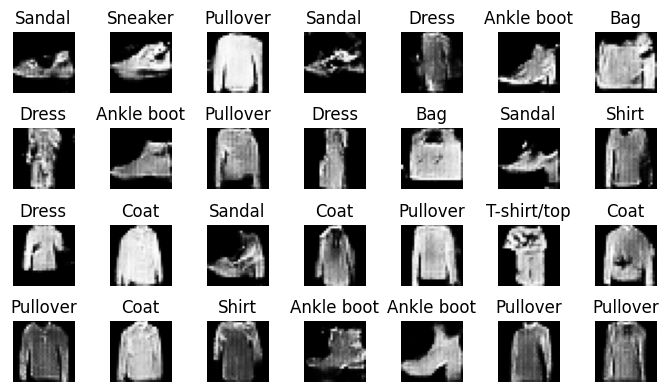

In [ ]:
imagens, rotulos = gerar_aleatorio(
    modelo_gerador,   # gerador condicional
    device,           # dispositivo: 'cpu' ou 'cuda'
    z_dim=z_dim,      # dimensão do vetor latente
    n_images=28,      # número de imagens que desejamos gerar
    num_classes=10    # número de classes do conjunto de dados
)

# Chama a função para plotar as imagens em grade
plot_multiple_images(imagens, rotulos, n_cols=7)

In [ ]:
# Gera n imagens para uma única classe (mantendo o rótulo fixo e variando o ruído)
def gerar_imagens_por_classe(modelo_gerador, device, classe_especifica, n_images=20, z_dim=100, num_classes=10):
    modelo_gerador.eval()  # Modo de avaliação

    # Vetores de ruído aleatórios
    z = torch.randn((n_images, z_dim), device=device)

    # Rótulo fixo
    rotulos = torch.full((n_images,), classe_especifica, device=device, dtype=torch.long)

    # Converte para one-hot
    rotulos_one_hot = F.one_hot(rotulos, num_classes=num_classes).float()

    # Gera as imagens com o gerador condicional
    with torch.no_grad():
        imagens_geradas = modelo_gerador(z, rotulos_one_hot)
        imagens_geradas = imagens_geradas.detach().cpu().numpy()

    return imagens_geradas, rotulos

In [ ]:
# Função para plotar várias imagens em um grid
def plot_multiple_images(imagens, n_cols=7):
    n_rows = (len(imagens) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, img in enumerate(imagens):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        plt.axis("off")
    plt.tight_layout(pad=1.0, w_pad=0.5, h_pad=1.0)
    plt.show()

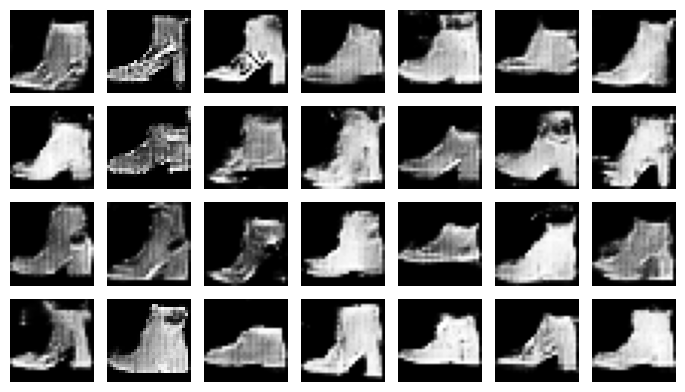

In [ ]:
imagens, rotulos = gerar_imagens_por_classe(
    modelo_gerador,
    device,
    classe_especifica=9,
    n_images=28,
    z_dim=z_dim,
    num_classes=10
)

plot_multiple_images(imagens, n_cols=7)

## Evolução das saídas do gerador para um vetor latente fixo durante o treinamento

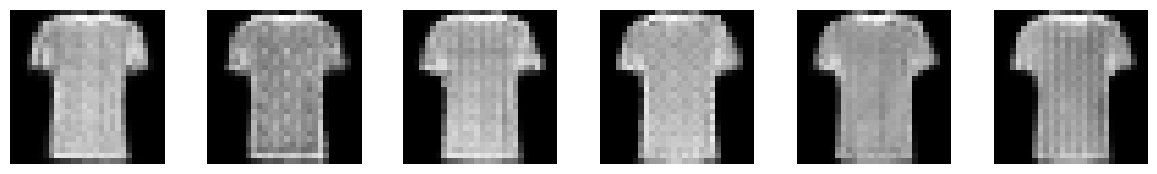

In [ ]:
# Lista com imagens 8x8
imagens = evolução_dado_falso

# Cria subplots (1 linha, -1 colunas)
fig, axes = plt.subplots(1, len(evolução_dado_falso), figsize=(15, 2))

# Itera por cada subplot e mostra a imagem
for ax, img in zip(axes, imagens):
    ax.imshow(img, cmap='gray')    # 1 = preto, 0 = branco
    ax.axis('off')                 # Remove ticks dos eixos

# ajusta o espaçamento entre subplots
plt.subplots_adjust(wspace=0.1)  # aumente para um maior espaçamento entre as imagens

plt.show()

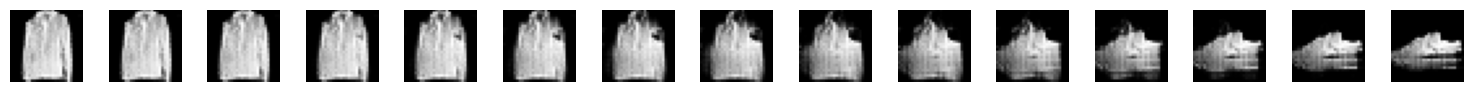

In [ ]:
def interp_z_fixo(
    gerador,
    device,
    z_dim=100,
    num_classes=10,
    classe_1=0,
    classe_2=9,
    steps=10,
    seed=42,
):
    torch.manual_seed(seed)  # Define a semente para reprodutibilidade

    # Gera um vetor de ruído fixo (z) com dimensão z_dim
    z_fix = torch.randn((1, z_dim), device=device)

    # Cria os vetores one-hot correspondentes às classes iniciais e finais
    c1 = F.one_hot(torch.tensor([classe_1], device=device), num_classes).float()
    c2 = F.one_hot(torch.tensor([classe_2], device=device), num_classes).float()

    # Cria valores entre 0 e 1 igualmente espaçados para interpolação
    alphas = torch.linspace(0, 1, steps, device=device)

    # Expande os rótulos iniciais e finais para steps linhas
    c1_b = c1.expand(steps, -1)
    c2_b = c2.expand(steps, -1)

    # Interpola linearmente entre c1 e c2 ao longo de steps
    c_seq = torch.lerp(c1_b, c2_b, alphas.view(-1, 1))      # lerp(a,b,alpha) = (1 - alpha) * a + alpha * b

    # Repete o mesmo vetor z_fix para todos os steps
    z_batch = z_fix.expand(steps, -1)

    # Desativa o cálculo de gradientes durante a geração
    with torch.no_grad():
        gerador.eval()
        imgs = gerador(z_batch, c_seq)

    # Converte cada imagem gerada para numpy e remove dimensões extras
    interpolados = [img.squeeze().cpu().numpy() for img in imgs]

    # Plota as imagens em um grid
    plot_multiple_images(interpolados, n_cols=steps)

    return


interp_z_fixo(
    gerador=modelo_gerador,
    device=device,
    z_dim=z_dim,        # dimensão latente usada no treinamento
    num_classes=10,     # número de classes do conjunto de dados
    classe_1=2,         # classe 1
    classe_2=7,         # classe 2
    steps=15,           # número de passos da interpolação
    seed=5              # semente para reprodutibilidade
)


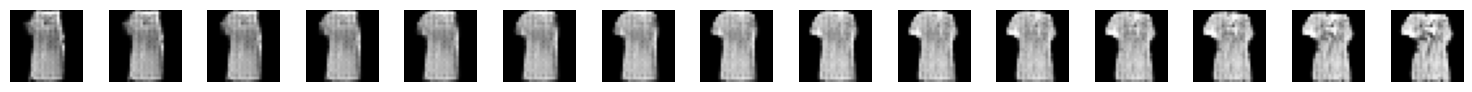

In [ ]:
def interp_c_fixo(
    gerador,
    device,
    z_dim=100,
    num_classes=10,
    classe_fixa=0,
    steps=10,
    seed=42,
):
    torch.manual_seed(seed)  # Define a semente para reprodutibilidade

    # Gera dois vetores de ruído aleatórios (z1 e z2), que serão os pontos extremos da interpolação
    z1 = torch.randn((1, z_dim), device=device)
    z2 = torch.randn((1, z_dim), device=device)

    # Cria o vetor one-hot correspondente ao rótulo fixo
    c_fix = F.one_hot(torch.tensor([classe_fixa], device=device), num_classes).float()

    # Cria valores entre 0 e 1 igualmente espaçados para interpolação
    alphas = torch.linspace(0, 1, steps, device=device)

    # Expande os vetores z1 e z2 para steps linhas
    z1_b = z1.expand(steps, -1)
    z2_b = z2.expand(steps, -1)

    # Interpola linearmente entre z1 e z2 ao longo de steps: (1 - alpha) * z1_b + alpha * z2_b
    z_seq = torch.lerp(z1_b, z2_b, alphas.view(-1, 1))

    # Repete o mesmo rótulo fixo para todos os steps
    c_batch = c_fix.expand(steps, -1)

    # Desativa o cálculo de gradientes durante a geração
    with torch.no_grad():
        gerador.eval()
        imgs = gerador(z_seq, c_batch)

    # Converte cada imagem gerada para numpy e remove dimensões extras
    interpolados = [img.squeeze().cpu().numpy() for img in imgs]

    # Plota as imagens em um grid
    plot_multiple_images(interpolados, n_cols=steps)

    return

interp_c_fixo(
    gerador=modelo_gerador,
    device=device,
    z_dim=z_dim,        # dimensão latente usada no treinamento
    num_classes=10,     # número de classes do conjunto de dados
    classe_fixa=0,      # rótulo fixo escolhido
    steps=15,           # número de passos da interpolação
    seed=0              # semente para reprodutibilidade
)


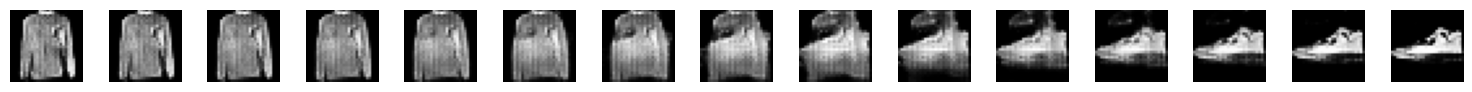

In [ ]:
def interp_z_e_c(
    gerador,
    device,
    z_dim=100,
    num_classes=10,
    classe_1=0,
    classe_2=9,
    steps=10,
    seed=42,
):
    torch.manual_seed(seed)  # Define a semente para reprodutibilidade

    # Gera dois vetores de ruído aleatórios (z1 e z2), que serão os pontos extremos da interpolação
    z1 = torch.randn((1, z_dim), device=device)
    z2 = torch.randn((1, z_dim), device=device)

    # Cria os vetores one-hot correspondentes às classes inicial e final
    c1 = F.one_hot(torch.tensor([classe_1], device=device), num_classes).float()
    c2 = F.one_hot(torch.tensor([classe_2], device=device), num_classes).float()

    # Cria valores entre 0 e 1 igualmente espaçados para interpolação
    alphas = torch.linspace(0, 1, steps, device=device)

    # Interpola linearmente entre z1 e z2 ao longo de steps: (1 - alpha) * z1_b + alpha * z2_b
    z1_b = z1.expand(steps, -1)
    z2_b = z2.expand(steps, -1)
    z_seq = torch.lerp(z1_b, z2_b, alphas.view(-1, 1))

    # Interpola linearmente entre c1 e c2 ao longo de steps (rótulos suaves): (1 - alpha) * c1_b + alpha * c2_b
    c1_b = c1.expand(steps, -1)
    c2_b = c2.expand(steps, -1)
    c_seq = torch.lerp(c1_b, c2_b, alphas.view(-1, 1))

    # Desativa o cálculo de gradientes durante a geração
    with torch.no_grad():
        gerador.eval()
        imgs = gerador(z_seq, c_seq)

    # Converte cada imagem gerada para numpy e remove dimensões extras
    interpolados = [img.squeeze().cpu().numpy() for img in imgs]

    # Plota as imagens em um grid
    plot_multiple_images(interpolados, n_cols=steps)

    return

interp_z_e_c(
    gerador=modelo_gerador,
    device=device,
    z_dim=z_dim,        # dimensão latente usada no treinamento
    num_classes=10,     # número de classes do conjunto de dados
    classe_1=2,         # classe inicial
    classe_2=7,         # classe final
    steps=15,           # número de passos da interpolação
    seed=1              # semente para reprodutibilidade
)

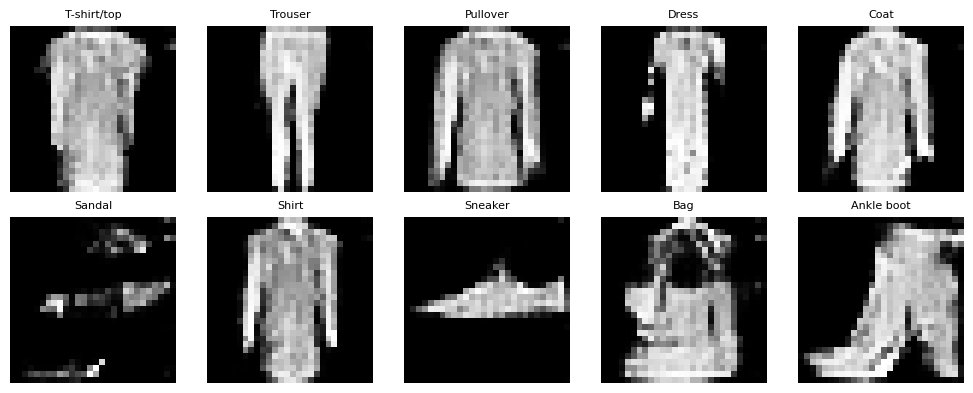

In [ ]:
def variar_classe_fixa_z(gerador, device, z_dim=100, num_classes=10):
    # Gera um único vetor de ruído aleatório e o repete para todas as classes
    # Assim, apenas o rótulo varia enquanto o ruído (z) permanece fixo
    z = torch.randn((1, z_dim), device=device).repeat(num_classes, 1)

    # Cria um vetor com todas as classes (0 a num_classes-1)
    classes = torch.arange(0, num_classes, device=device)

    # Converte cada classe para representação one-hot
    rotulos_one_hot = F.one_hot(classes, num_classes=num_classes).float()

    # Desativa o cálculo de gradientes durante a geração
    with torch.no_grad():
        gerador.eval()
        imagens = gerador(z, rotulos_one_hot).cpu().numpy()

    # Lista de nomes correspondentes às classes do FashionMNIST
    nomes_classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                     "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

    # Define o layout da grade para visualização
    n_cols = 5
    n_rows = (num_classes - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2))

    # Plota cada imagem correspondente ao rótulo fixo de z
    for i, (img, nome) in enumerate(zip(imagens, nomes_classes)):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        plt.title(nome, fontsize=8)
        plt.axis("off")

    # Ajusta espaçamentos da figura
    plt.tight_layout()
    plt.show()


variar_classe_fixa_z(modelo_gerador, device, z_dim=z_dim)